# Info

Author: Xiaoqian Sun </br>
Created: 07/28/2025 </br>
Function: Analysis on Signal Level
- create a vector of indicators to describe CCGs
- correlate each indicator with perturbation strength
- regress model performance on these indicators
- cluster perturbations by CCG types to identify which combinations are most harmful

### Entropy
Entropy doesn't care whether bins are positive or negative. It only cares how unevenly values are distributed after normalization to a probability distribution.
Measures the overall unpredictability of a distribution
- A flat (uniform) CCG → high entropy (close to log₂(N))
- A sharp peak or dip → lower entropy (because values are unevenly distributed)

### KL Divergence
KL divergence highlights how far the actual shape is from "flat randomness." Unlike entropy, KL requires defining a reference distribution (here, uniform).
- If bins are all equal → KL divergence is 0
- If a few bins dominate (e.g., a peak or dip near 0 ms) → KL divergence increases

### Intuition
- Entropy is absolute — it measures how spread out the probability mass is.
- KL divergence is relative — it measures how far the current distribution is from a baseline (like uniform).

In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
from Functions import *
import matplotlib.pyplot as plt
from scipy.stats import entropy
from scipy.special import rel_entr
from scipy.ndimage import gaussian_filter1d

import warnings
warnings.filterwarnings('ignore')

# Path & Common File & Parameters

In [3]:
# path --------------------------------------------------
root_path = r'/Users/xiaoqiansun/Desktop/InferConnectivity'
work_path = os.getcwd()

dataloader_path = os.path.join(work_path, 'dataloader')

result_path = os.path.join(work_path, 'Result')
allRuns_path = os.path.join(result_path, 'all120Runs')

resultAnalysis_path = os.path.join(work_path, 'resultAnalysis')
indiSave_path = os.path.join(resultAnalysis_path, 'indi'); os.makedirs(indiSave_path, exist_ok=True)
confiSave_path = os.path.join(resultAnalysis_path, 'fmm_confi'); os.makedirs(confiSave_path, exist_ok=True)

data_path = os.path.join(root_path, 'Dataset', 'm2post')
info_df = pd.read_csv(os.path.join(dataloader_path, 'binInfo.csv')).iloc[:, 1:]
bin_size=1; timebins = info_df['t']

# Para --------------------------------------------------
# baseline_types = ['E3', 'E5', 'E8', 'g0.5', 'g1.5']
baseline_types = ['E3', 'E5', 'E8', 'g0.5', 'g1.5', 'BP0.5', 'mu165', 'mu180', 'tau5', 'tau40']
perturbations = ['mu', 'tau', 'BP', 'EI', 'Weight']

indicators_exc = ['peak_height', 'peak_lag', 'peak_halfMax_width', 'peak_to_noise', 'temporal_span', 'entropy', 'norm_entropy', 'norm_entropy_window', 'kl_divergence_window']
indicators_inh = ['dip_depth', 'dip_lag', 'dip_halfMax_width', 'dip_to_noise', 'temporal_span', 'entropy', 'norm_entropy', 'norm_entropy_window', 'kl_divergence_window']

cmap= 'coolwarm'; cm_cmap='PuBu'; 
mC='firebrick'; bC='steelblue'; ccgColor='k'
coolwarm_blue = '#3B4CC0'; coolwarm_red = '#B40426'
coolwarm_softblue = '#6BAED6'; coolwarm_softred = '#E07A7A’; correctGREEN= '#2E7D32'


# Indicator - Just Ran Once

In [4]:
# bs_Idx = 1
# baselineType = baseline_types[bs_Idx]
# baselineName = 'baseline'#'baseline_E3'

# base_mu = 150
# base_tau = 15
# base_BP = 1.0
# base_EI = 0.5
# base_g = 1.0
# dataPrefix = '_'+baselineType
# bs_featureDic = [{'mu':base_mu, 'tau':base_tau, 'BP':base_BP, 'EI':base_EI, 'g': base_g}]

# print('  - baseline', dataPrefix, 'with base values:', bs_featureDic)

  - baseline _E5 with base values: [{'mu': 150, 'tau': 15, 'BP': 1.0, 'EI': 0.5, 'g': 1.0}]


In [5]:
# mus = [150+2*i for i in range(16)]
# mu_prefix = ['mu'+str(mu) for mu in mus]
# mu_tests  = ['mu'+dataPrefix+str(mu) for mu in mus] if ('mu' not in dataPrefix and 'E5' not in dataPrefix) else mu_prefix
# mu_featureDics = [{'mu':mu, 'tau':base_tau, 'BP':base_BP, 'EI':base_EI, 'g':base_g } for mu in mus]


# taus = [5*i for i in range(1, 11)]
# tau_prefix = ['tau'+str(tau) for tau in taus]
# tau_tests  = ['tau'+dataPrefix+str(tau) for tau in taus] if ('tau' not in dataPrefix and 'E5' not in dataPrefix) else tau_prefix
# tau_featureDics = [{'mu':base_mu, 'tau':tau, 'BP':base_BP, 'EI':base_EI, 'g':base_g } for tau in taus]


# BPs = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
# BP_prefix = ['BP'+str(BP) for BP in BPs]
# BP_tests  = ['BP'+dataPrefix+str(BP) for BP in BPs] if ('BP' not in dataPrefix and 'E5' not in dataPrefix) else BP_prefix
# BP_featureDics = [{'mu':base_mu, 'tau':base_tau, 'BP':BP, 'EI':base_EI, 'g':base_g } for BP in BPs]


# EIs = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
# EI_prefix  = ['EI'+str(EI) for EI in EIs]
# EI_tests  = ['EI'+dataPrefix+str(EI) for EI in EIs] if ('E' not in dataPrefix and 'E5' not in dataPrefix) else EI_prefix
# EI_featureDics = [{'mu':base_mu, 'tau':base_tau, 'BP':base_BP, 'EI':EI, 'g':base_g } for EI in EIs]


# gs = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]
# gbar_prefix = ['g'+str(g) for g in gs]
# gbar_tests = ['g'+dataPrefix+str(g) for g in gs] if ('g' not in dataPrefix and 'E5' not in dataPrefix) else gbar_prefix
# g_featureDics = [{'mu':base_mu, 'tau':base_tau, 'BP':base_BP, 'EI':base_EI, 'g': g} for g in gs] 


# file_test_list = [baselineName] + mu_tests + tau_tests + BP_tests + EI_tests + gbar_tests
# file_prefix_list = ['baseline'] + mu_prefix + tau_prefix + BP_prefix + EI_prefix + gbar_prefix
# file_featureDics = bs_featureDic + mu_featureDics + tau_featureDics + BP_featureDics + EI_featureDics + g_featureDics

# print(len(file_prefix_list), '= 1 baseline + 48 perturbations')

49 = 1 baseline + 48 perturbations


In [5]:
# indicator_exc_list = []; indicator_inh_list = []
# for i in range(len(file_test_list)):
#     fileTest = file_test_list[i]
#     featureDic = file_featureDics[i]
#     try:
#         ccg, ws, ls, ss = read_ccg(data_path, fileTest+'_CCG.csv') 
    
#         for nIdx in range(len(ccg)):
#             w = ws[nIdx]; sname = ss[nIdx]
#             if w > 0:
#                 indi = ccg_indicators(ccg[nIdx], connection_type='exc', smoothSigma=0.5, bin_size=1, peak_window_ms=10, ifVerbose=False,ifPlot=False,ifSave=False)
#                 indi.update(featureDic); indi['Weight'] = w; indi['sample']=sname; indi['test']=fileTest
#                 indicator_exc_list.append(indi)
#             elif w < 0:
#                 indi = ccg_indicators(ccg[nIdx], connection_type='inh', smoothSigma=0.5, bin_size=1, peak_window_ms=10, ifVerbose=False,ifPlot=False,ifSave=False)
#                 indi.update(featureDic); indi['Weight'] = w; indi['sample']=sname; indi['test']=fileTest
#                 indicator_inh_list.append(indi)
#     except Exception as e:
#         print(fileTest, '--', e)

#     break

# indicatorExc_df=pd.DataFrame(indicator_exc_list);# indicatorExc_df.to_csv(os.path.join(indiSave_path, baselineType+'_indicator_exc.csv'))
# indicatorInh_df=pd.DataFrame(indicator_inh_list);# indicatorInh_df.to_csv(os.path.join(indiSave_path, baselineType+'_indicator_inh.csv'))
# print(indicatorExc_df.shape, indicatorInh_df.shape); indicatorInh_df.tail(5)

(100, 17) (100, 17)


,dip_depth,dip_lag,dip_halfMax_width,dip_to_noise,temporal_span,entropy,norm_entropy,norm_entropy_window,kl_divergence_window,mu,tau,BP,EI,g,Weight,sample,test
95,53.0,1,7,4.131150,7,6.648507,0.998542,0.994371,0.024722,150,15,1.0,0.5,1.0,-0.7,baseline_4_Pre_I15_Post,baseline
96,54.0,1,9,4.340943,8,6.648042,0.998473,0.993391,0.029031,150,15,1.0,0.5,1.0,-0.7,baseline_4_Pre_I16_Post,baseline
97,45.0,5,2,5.237189,8,6.645984,0.998164,0.992909,0.031148,150,15,1.0,0.5,1.0,-0.7,baseline_4_Pre_I17_Post,baseline
98,58.0,8,8,3.501930,8,6.649007,0.998618,0.994141,0.025734,150,15,1.0,0.5,1.0,-0.7,baseline_4_Pre_I18_Post,baseline
99,46.0,1,8,4.645805,8,6.646124,0.998185,0.991752,0.036227,150,15,1.0,0.5,1.0,-0.7,baseline_4_Pre_I19_Post,baseline


# ----------------------------------------------------------------------

# FMM, Confi, Indi

### loader best M

In [4]:
baseline_types = ['E3', 'E5', 'E8', 'g0.5', 'g1.5', 'BP0.5', 'mu165', 'mu180', 'tau5', 'tau40']


model, optimizer, scheduler, criterion = init_conn_model()
connCNNE3,_ = load_conn_model(model,optimizer,scheduler,savePath=allRuns_path, filename='ConnCNN_E3_100.0.pth')

model, optimizer, scheduler, criterion = init_conn_model()
connCNNE5,_ = load_conn_model(model,optimizer,scheduler,savePath=allRuns_path, filename='ConnCNN_E5_100.0.pth')

model, optimizer, scheduler, criterion = init_conn_model()
connCNNE8,_ = load_conn_model(model,optimizer,scheduler,savePath=allRuns_path, filename='ConnCNN_E8_100.0.pth')

model, optimizer, scheduler, criterion = init_conn_model()
connCNNg05,_ = load_conn_model(model,optimizer,scheduler,savePath=allRuns_path, filename='ConnCNN_g0.5_100.0.pth')

model, optimizer, scheduler, criterion = init_conn_model()
connCNNg15,_ = load_conn_model(model,optimizer,scheduler,savePath=allRuns_path, filename='ConnCNN_g1.5_100.0.pth')

model, optimizer, scheduler, criterion = init_conn_model()
connCNNBP05,_ = load_conn_model(model,optimizer,scheduler,savePath=allRuns_path, filename='ConnCNN_BP0.5_100.0.pth')

model, optimizer, scheduler, criterion = init_conn_model()
connCNNmu165,_ = load_conn_model(model,optimizer,scheduler,savePath=allRuns_path, filename='ConnCNN_mu165_100.0.pth')

model, optimizer, scheduler, criterion = init_conn_model()
connCNNmu180,_ = load_conn_model(model,optimizer,scheduler,savePath=allRuns_path, filename='ConnCNN_mu180_100.0.pth')

model, optimizer, scheduler, criterion = init_conn_model()
connCNNtau5,_ = load_conn_model(model,optimizer,scheduler,savePath=allRuns_path, filename='ConnCNN_tau5_100.0.pth')

model, optimizer, scheduler, criterion = init_conn_model()
connCNNtau40,_ = load_conn_model(model,optimizer,scheduler,savePath=allRuns_path, filename='ConnCNN_tau40_100.0.pth')


baseline_connCNN_models = [connCNNE3, connCNNE5, connCNNE8, connCNNg05, connCNNg15, 
                           connCNNBP05, connCNNmu165, connCNNmu180, connCNNtau5, connCNNtau40]

Model loaded successfully from ConnCNN_E3_100.0.pth
Model loaded successfully from ConnCNN_E5_100.0.pth
Model loaded successfully from ConnCNN_E8_100.0.pth
Model loaded successfully from ConnCNN_g0.5_100.0.pth
Model loaded successfully from ConnCNN_g1.5_100.0.pth
Model loaded successfully from ConnCNN_BP0.5_100.0.pth
Model loaded successfully from ConnCNN_mu165_100.0.pth
Model loaded successfully from ConnCNN_mu180_100.0.pth
Model loaded successfully from ConnCNN_tau5_100.0.pth
Model loaded successfully from ConnCNN_tau40_100.0.pth


In [5]:
model, optimizer, scheduler, criterion = init_weight_model()
weighCNNE3,_ = load_model(model,optimizer,scheduler,savePath=allRuns_path, filename='w_E3_0.0096.pth')

model, optimizer, scheduler, criterion = init_weight_model()
weighCNNE5,_ = load_model(model,optimizer,scheduler,savePath=allRuns_path, filename='w_E5_0.0016.pth')

model, optimizer, scheduler, criterion = init_weight_model()
weighCNNE8,_ = load_model(model,optimizer,scheduler,savePath=allRuns_path, filename='w_E8_0.0003.pth')

model, optimizer, scheduler, criterion = init_weight_model()
weighCNNg05,_ = load_model(model,optimizer,scheduler,savePath=allRuns_path, filename='w_g0.5_0.0001.pth')

model, optimizer, scheduler, criterion = init_weight_model()
weighCNNg15,_ = load_model(model,optimizer,scheduler,savePath=allRuns_path, filename='w_g1.5_0.0024.pth')

model, optimizer, scheduler, criterion = init_weight_model()
weighCNNBP05,_ = load_model(model,optimizer,scheduler,savePath=allRuns_path, filename='w_BP0.5_0.0001.pth')

model, optimizer, scheduler, criterion = init_weight_model()
weighCNNmu165,_ = load_model(model,optimizer,scheduler,savePath=allRuns_path, filename='w_mu165_0.0033.pth')

model, optimizer, scheduler, criterion = init_weight_model()
weighCNNmu180,_ = load_model(model,optimizer,scheduler,savePath=allRuns_path, filename='w_mu180_0.0005.pth')

model, optimizer, scheduler, criterion = init_weight_model()
weighCNNtau5,_ = load_model(model,optimizer,scheduler,savePath=allRuns_path, filename='w_tau5_0.0001.pth')

model, optimizer, scheduler, criterion = init_weight_model()
weighCNNtau40,_ = load_model(model,optimizer,scheduler,savePath=allRuns_path, filename='w_tau40_0.0002.pth')

baseline_weightCNN_models = [weighCNNE3, weighCNNE5, weighCNNE8, weighCNNg05, weighCNNg15, 
                             weighCNNBP05, weighCNNmu165, weighCNNmu180, weighCNNtau5, weighCNNtau40]

Model loaded successfully from w_E3_0.0096.pth
Model loaded successfully from w_E5_0.0016.pth
Model loaded successfully from w_E8_0.0003.pth
Model loaded successfully from w_g0.5_0.0001.pth
Model loaded successfully from w_g1.5_0.0024.pth
Model loaded successfully from w_BP0.5_0.0001.pth
Model loaded successfully from w_mu165_0.0033.pth
Model loaded successfully from w_mu180_0.0005.pth
Model loaded successfully from w_tau5_0.0001.pth
Model loaded successfully from w_tau40_0.0002.pth


### perbs list

In [6]:
mu_prefix   = ['mu'+str(150+2*i) for i in range(16)]
muE3_prefix = ['mu_E3'+str(150+2*i) for i in range(16)]
muE8_prefix = ['mu_E8'+str(150+2*i) for i in range(16)]
mug05_prefix = ['mu_g0.5'+str(150+2*i) for i in range(16)] 
mug15_prefix = ['mu_g1.5'+str(150+2*i) for i in range(16)]
muBP05_prefix = ['mu_BP0.5'+str(150+2*i) for i in range(16)]
mutau5_prefix = ['mu_tau5'+str(150+2*i) for i in range(16)]
mutau40_prefix = ['mu_tau40'+str(150+2*i) for i in range(16)]


tau_prefix  = ['tau'+str(5*i) for i in range(1, 11)]
tauE3_prefix = ['tau_E3'+str(5*i) for i in range(1, 11)]
tauE8_prefix = ['tau_E8'+str(5*i) for i in range(1, 11)]
taug05_prefix = ['tau_g0.5'+str(5*i) for i in range(1, 11)]
taug15_prefix = ['tau_g1.5'+str(5*i) for i in range(1, 11)]
tauBP05_prefix = ['tau_BP0.5'+str(5*i) for i in range(1, 11)]
taumu165_prefix = ['tau_mu165'+str(5*i) for i in range(1, 11)]
taumu180_prefix = ['tau_mu180'+str(5*i) for i in range(1, 11)]


BPs = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
BP_prefix   = ['BP'+str(bp) for bp in BPs]
BPE3_prefix = ['BP_E3'+str(bp) for bp in BPs]
BPE8_prefix = ['BP_E8'+str(bp) for bp in BPs]
BPg05_prefix = ['BP_g0.5'+str(bp) for bp in BPs] 
BPg15_prefix = ['BP_g1.5'+str(bp) for bp in BPs]
BPmu165_prefix = ['BP_mu165'+str(bp) for bp in BPs]
BPmu180_prefix = ['BP_mu180'+str(bp) for bp in BPs]
BPtau5_prefix = ['BP_tau5'+str(bp) for bp in BPs]
BPtau40_prefix = ['BP_tau40'+str(bp) for bp in BPs]


EIatio=[0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
EI_prefix  = ['EI'+str(ei) for ei in EIatio]
EIg05_prefix = ['EI_g0.5'+str(ei) for ei in EIatio] ; EIg05_prefix.remove('EI_g0.50.3')
EIg15_prefix = ['EI_g1.5'+str(ei) for ei in EIatio]
EIBP05_prefix = ['EI_BP0.5'+str(ei) for ei in EIatio]
EImu165_prefix = ['EI_mu165'+str(ei) for ei in EIatio]
EImu180_prefix = ['EI_mu180'+str(ei) for ei in EIatio]
EItau5_prefix = ['EI_tau5'+str(ei) for ei in EIatio]
EItau40_prefix = ['EI_tau40'+str(ei) for ei in EIatio]


gbars = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]
gbar_prefix = ['g'+str(g) for g in gbars]
gbarE3_prefix = ['g_E3'+str(g) for g in gbars] ; gbarE3_prefix.remove('g_E30.4')
gbarE8_prefix = ['g_E8'+str(g) for g in gbars]
gbarBP05_prefix = ['g_BP0.5'+str(g) for g in gbars]; gbarBP05_prefix.remove('g_BP0.50.4')
gbarmu165_prefix = ['g_mu165'+str(g) for g in gbars]; gbarmu165_prefix.remove('g_mu1650.4')
gbarmu180_prefix = ['g_mu180'+str(g) for g in gbars]; gbarmu180_prefix.remove('g_mu1800.4')
gbartau5_prefix = ['g_tau5'+str(g) for g in gbars]; gbartau5_prefix.remove('g_tau50.4')
gbartau40_prefix = ['g_tau40'+str(g) for g in gbars]; gbartau40_prefix.remove('g_tau400.4')


file_prefix_E5_list = mu_prefix + tau_prefix + BP_prefix + EI_prefix + gbar_prefix
file_prefix_E3_list = muE3_prefix + tauE3_prefix + BPE3_prefix + EI_prefix + gbarE3_prefix
file_prefix_E8_list = muE8_prefix + tauE8_prefix + BPE8_prefix + EI_prefix + gbarE8_prefix
file_prefix_g05_list = mug05_prefix + taug05_prefix + BPg05_prefix + EIg05_prefix + gbar_prefix
file_prefix_g15_list = mug15_prefix + taug15_prefix + BPg15_prefix + EIg15_prefix + gbar_prefix
file_prefix_BP05_list = muBP05_prefix + tauBP05_prefix + BP_prefix + EIBP05_prefix + gbarBP05_prefix
file_prefix_mu165_list = mu_prefix + taumu165_prefix + BPmu165_prefix + EImu165_prefix + gbarmu165_prefix
file_prefix_mu180_list = mu_prefix + taumu180_prefix + BPmu180_prefix + EImu180_prefix + gbarmu180_prefix
file_prefix_tau5_list = mutau5_prefix + tau_prefix + BPtau5_prefix + EItau5_prefix + gbartau5_prefix
file_prefix_tau40_list = mutau40_prefix + tau_prefix + BPtau40_prefix + EItau40_prefix + gbartau40_prefix


file_prefix_lists = [file_prefix_E3_list, file_prefix_E5_list, file_prefix_E8_list, file_prefix_g05_list, file_prefix_g15_list,
                    file_prefix_BP05_list, file_prefix_mu165_list, file_prefix_mu180_list, file_prefix_tau5_list, file_prefix_tau40_list]
perturbation_loader_lists = [ [load_oneLoader(dataloader_path, file_prefix+'_loader.pkl') for file_prefix in file_prefix_list] for file_prefix_list in file_prefix_lists ]


### calculation

In [78]:
criterionC = nn.BCEWithLogitsLoss()
criterionW = HuberLossWithWeight()
fm_mean_cols = ['conv1_fm0_mean', 'conv1_fm1_mean', 'conv1_fm2_mean', 'conv1_fm3_mean', 'conv2_fm0_mean', 'conv2_fm1_mean']

for bIdx in range(len(baseline_types)):

    predSummary_list = []
    
    # retrive the best baseline model ---------------------------------------------------------------
    bsType = baseline_types[bIdx]
    connCNN_Model = baseline_connCNN_models[bIdx]
    weightCNN_Model = baseline_weightCNN_models[bIdx]
    

    # predict on baseline-test set -------------------------------------------------------------------
    train_loader, val_loader, test_loader = load_dataloaders(dataloader_path, 'baseline_'+bsType+'_loader.pkl')

    # pred with connCNN ------------
    avg_connect_loss, accu, pred_list,confi_list, label_list, w_list, sCInfo_list = evaluateConnCNN_wConfi_model(connCNN_Model, test_loader, criterionC)

    # pred with weightCNN ----------
    avg_wegiht_loss, predW_list, gtW_list, label0_loss, label1_loss, sWInfo_list = evaluateWeightCNN_model(weightCNN_Model, test_loader, criterionW)

    # feature map mean -------------
    conn_fmMean_list = []; weight_fmMean_list = []
    conn_fmMean_pre_list = []; weight_fmMean_pre_list = []
    conn_fmMean_postBN_list = []; weight_fmMean_postBN_list = []
    for ccgs, cs, ws, ss in test_loader:
        for m in range(len(ccgs)):

            # pre activation (raw featureMaps)
            fm_conv1, fm_conv2, activation_1, activation_2 = cal_feature_maps(connCNN_Model, ccgs[m])  # connCNN
            conn_fmMean_pre_list.append(fm_conv1.mean(dim=1).tolist() + fm_conv2.mean(dim=1).tolist())
            fm_conv1, fm_conv2, activation_1, activation_2 = cal_feature_maps(weightCNN_Model, ccgs[m])# weightCNN
            weight_fmMean_pre_list.append(fm_conv1.mean(dim=1).tolist() + fm_conv2.mean(dim=1).tolist())

            # postBN (featureMaps after BatchNorm, but before tanh)
            fm_conv1, fm_conv2, activation_1, activation_2 = cal_feature_maps_postBN(connCNN_Model, ccgs[m])  # connCNN
            conn_fmMean_postBN_list.append(fm_conv1.mean(dim=1).tolist() + fm_conv2.mean(dim=1).tolist())
            fm_conv1, fm_conv2, activation_1, activation_2 = cal_feature_maps_postBN(weightCNN_Model, ccgs[m])# weightCNN
            weight_fmMean_postBN_list.append(fm_conv1.mean(dim=1).tolist() + fm_conv2.mean(dim=1).tolist())

            # post activation (featureMaps after BatchNorm & tanh)
            fm_conv1, fm_conv2, activation_1, activation_2 = cal_feature_maps_post_activation(connCNN_Model, ccgs[m])  # connCNN
            conn_fmMean_list.append(fm_conv1.mean(dim=1).tolist() + fm_conv2.mean(dim=1).tolist())
            fm_conv1, fm_conv2, activation_1, activation_2 = cal_feature_maps_post_activation(weightCNN_Model, ccgs[m])# weightCNN
            weight_fmMean_list.append(fm_conv1.mean(dim=1).tolist() + fm_conv2.mean(dim=1).tolist())
            
    
    predSummary = pd.DataFrame([label_list, pred_list, confi_list, gtW_list, predW_list, sCInfo_list, ['baseline_'+bsType]*len(sCInfo_list)], 
                                index=['connLabel', 'predLabel', 'confi', 'gtWeights', 'predWeights', 'sample', 'test']).T   
    connPre_FMM = pd.DataFrame(np.array(conn_fmMean_pre_list), columns=['pre_conn_'+col for col in fm_mean_cols])
    connPost_FMM = pd.DataFrame(np.array(conn_fmMean_list), columns=['post_conn_'+col for col in fm_mean_cols])
    connPostBN_FMM = pd.DataFrame(np.array(conn_fmMean_postBN_list), columns=['postBN_conn_'+col for col in fm_mean_cols])
    
    weightPre_FMM = pd.DataFrame(np.array(weight_fmMean_pre_list), columns=['pre_weight_'+col for col in fm_mean_cols])
    weightPost_FMM = pd.DataFrame(np.array(weight_fmMean_list), columns=['post_weight_'+col for col in fm_mean_cols])
    weightPostBN_FMM = pd.DataFrame(np.array(weight_fmMean_postBN_list), columns=['postBN_weight_'+col for col in fm_mean_cols])
    
    predSummary = pd.concat([predSummary, connPre_FMM, connPost_FMM, connPostBN_FMM, weightPre_FMM, weightPost_FMM, weightPostBN_FMM], axis=1); predSummary_list.append(predSummary)
    

    
    # predict on associated perturbations ------------------------------------------------------------
    file_prefix_list = file_prefix_lists[bIdx]
    perturbation_loader = perturbation_loader_lists[bIdx]
    for fileIdx in range(len(file_prefix_list)):
        perb_type = file_prefix_list[fileIdx]
        perb_loader = perturbation_loader[fileIdx]

        # pred with connCNN ------------
        avg_connect_loss, accu, pred_list,confi_list, label_list, w_list, sCInfo_list = evaluateConnCNN_wConfi_model(connCNN_Model, perb_loader, criterionC)

        # pred with weightCNN ----------
        avg_wegiht_loss, predW_list, gtW_list, label0_loss, label1_loss, sWInfo_list = evaluateWeightCNN_model(weightCNN_Model, perb_loader, criterionW)

        assert np.array_equal(sCInfo_list, sWInfo_list), bsType+' '+perb_type+" sInfo Arrays are not equal"

        # get feature map mean on each ccg -------------
        conn_fmMean_list = []; weight_fmMean_list = []
        conn_fmMean_pre_list = []; weight_fmMean_pre_list = []
        conn_fmMean_postBN_list = []; weight_fmMean_postBN_list = []
        for ccgs, cs, ws, ss in perb_loader:
            for m in range(len(ccgs)):

                # pre activation (raw featureMaps)
                fm_conv1, fm_conv2, activation_1, activation_2 = cal_feature_maps(connCNN_Model, ccgs[m])  # connCNN
                conn_fmMean_pre_list.append(fm_conv1.mean(dim=1).tolist() + fm_conv2.mean(dim=1).tolist())
                fm_conv1, fm_conv2, activation_1, activation_2 = cal_feature_maps(weightCNN_Model, ccgs[m])# weightCNN
                weight_fmMean_pre_list.append(fm_conv1.mean(dim=1).tolist() + fm_conv2.mean(dim=1).tolist())

                # postBN (featureMaps after BatchNorm, but before tanh)
                fm_conv1, fm_conv2, activation_1, activation_2 = cal_feature_maps_postBN(connCNN_Model, ccgs[m])  # connCNN
                conn_fmMean_postBN_list.append(fm_conv1.mean(dim=1).tolist() + fm_conv2.mean(dim=1).tolist())
                fm_conv1, fm_conv2, activation_1, activation_2 = cal_feature_maps_postBN(weightCNN_Model, ccgs[m])# weightCNN
                weight_fmMean_postBN_list.append(fm_conv1.mean(dim=1).tolist() + fm_conv2.mean(dim=1).tolist())

                # post activation (featureMaps after BatchNorm & tanh)
                fm_conv1, fm_conv2, activation_1, activation_2 = cal_feature_maps_post_activation(connCNN_Model, ccgs[m])
                conn_fmMean_list.append(fm_conv1.mean(dim=1).tolist() + fm_conv2.mean(dim=1).tolist())
                fm_conv1, fm_conv2, activation_1, activation_2 = cal_feature_maps_post_activation(weightCNN_Model, ccgs[m])
                weight_fmMean_list.append(fm_conv1.mean(dim=1).tolist() + fm_conv2.mean(dim=1).tolist())

        
        predSummary = pd.DataFrame([label_list, pred_list, confi_list, gtW_list, predW_list, sCInfo_list, [perb_type]*len(sCInfo_list)], 
                                   index=['connLabel', 'predLabel', 'confi', 'gtWeights', 'predWeights', 'sample', 'test']).T
        connPre_FMM = pd.DataFrame(np.array(conn_fmMean_pre_list), columns=['pre_conn_'+col for col in fm_mean_cols])
        connPost_FMM = pd.DataFrame(np.array(conn_fmMean_list), columns=['post_conn_'+col for col in fm_mean_cols])
        connPostBN_FMM = pd.DataFrame(np.array(conn_fmMean_postBN_list), columns=['postBN_conn_'+col for col in fm_mean_cols])
        
        weightPre_FMM = pd.DataFrame(np.array(weight_fmMean_pre_list), columns=['pre_weight_'+col for col in fm_mean_cols])
        weightPost_FMM = pd.DataFrame(np.array(weight_fmMean_list), columns=['post_weight_'+col for col in fm_mean_cols])
        weightPostBN_FMM = pd.DataFrame(np.array(weight_fmMean_postBN_list), columns=['postBN_weight_'+col for col in fm_mean_cols])
        
        predSummary = pd.concat([predSummary, connPre_FMM, connPost_FMM, connPostBN_FMM, weightPre_FMM, weightPost_FMM, weightPostBN_FMM], axis=1); predSummary_list.append(predSummary)
        

    bspredSummary = pd.concat(predSummary_list)
    bspredSummary.to_csv(os.path.join(confiSave_path, bsType+'_confi_w_perbs.csv'))


# baseline_types = ['E3', 'E5', 'E8', 'g0.5', 'g1.5', 'BP0.5', 'mu165', 'mu180', 'tau5', 'tau40']

print('Done')
bspredSummary.tail(2)

Done


,connLabel,predLabel,confi,gtWeights,predWeights,sample,test,pre_conn_conv1_fm0_mean,pre_conn_conv1_fm1_mean,pre_conn_conv1_fm2_mean,...,post_weight_conv1_fm2_mean,post_weight_conv1_fm3_mean,post_weight_conv2_fm0_mean,post_weight_conv2_fm1_mean,postBN_weight_conv1_fm0_mean,postBN_weight_conv1_fm1_mean,postBN_weight_conv1_fm2_mean,postBN_weight_conv1_fm3_mean,postBN_weight_conv2_fm0_mean,postBN_weight_conv2_fm1_mean
38,1.0,1.0,0.98315,-1.4,-0.757331,g_tau402.0_Pre_I18_Post,g_tau402.0,286.331848,131.601074,109.025070,...,0.204272,-0.475770,-0.945076,0.949860,-0.107944,0.004663,0.223553,-0.525204,-1.842015,1.847323
39,1.0,1.0,0.98072,-1.4,-0.760695,g_tau402.0_Pre_I19_Post,g_tau402.0,291.533081,133.360489,112.370819,...,0.233145,-0.476631,-0.941576,0.958106,-0.136025,0.008032,0.262762,-0.531321,-1.925319,1.973561


### combine FMM, Confi, Indictors


In [80]:
# baseline_types = ['E3', 'E5', 'E8', 'g0.5', 'g1.5', 'BP0.5', 'mu165', 'mu180', 'tau5', 'tau40']

for bIdx in range(len(baseline_types)):
    bsType = baseline_types[bIdx]
    bspredSummary = pd.read_csv(os.path.join(confiSave_path, bsType+'_confi_w_perbs.csv')).iloc[:, 1:]

    exc_indicator_df = pd.read_csv(os.path.join(indiSave_path, bsType+'_indicator_exc.csv')).iloc[:, 1:]
    inh_indicator_df = pd.read_csv(os.path.join(indiSave_path, bsType+'_indicator_inh.csv')).iloc[:, 1:]

    # merge
    pred_indi_exc = pd.merge(bspredSummary, exc_indicator_df, on='sample', how='inner')
    pred_indi_exc = pred_indi_exc.drop(columns=['test_y']); pred_indi_exc = pred_indi_exc.rename(columns={'test_x': 'test'})
    pred_indi_exc.to_csv(os.path.join(resultAnalysis_path, bsType+'_confi_fmm_indi_exc.csv'))
    
    pred_indi_inh = pd.merge(bspredSummary, inh_indicator_df, on='sample', how='inner')
    pred_indi_inh = pred_indi_inh.drop(columns=['test_y']); pred_indi_inh = pred_indi_inh.rename(columns={'test_x': 'test'})
    pred_indi_inh.to_csv(os.path.join(resultAnalysis_path, bsType+'_confi_fmm_indi_inh.csv'))


print('Done')
print(pred_indi_exc.shape); pred_indi_exc.head(2)

Done
(1319, 58)


,connLabel,predLabel,confi,gtWeights,predWeights,sample,test,pre_conn_conv1_fm0_mean,pre_conn_conv1_fm1_mean,pre_conn_conv1_fm2_mean,...,entropy,norm_entropy,norm_entropy_window,kl_divergence_window,mu,tau,BP,EI,g,Weight
0,1.0,1.0,0.986755,1.0,1.010784,baseline_tau40_3_Pre_E7_Post,baseline_tau40,183.772980,80.706551,59.358505,...,6.622784,0.994679,0.981759,0.080121,150,40.0,1.0,0.5,1.0,1.0
1,1.0,1.0,0.986755,1.0,1.012021,baseline_tau40_2_Pre_E11_Post,baseline_tau40,185.450607,81.569740,60.669697,...,6.617274,0.993852,0.976151,0.104752,150,40.0,1.0,0.5,1.0,1.0


## Best Model Accu/Loss

In [13]:
import re
def clean_test_value(val):
    # Remove patterns like _g0.5 or _BP0.5
    return re.sub(r'_g0\.5|_BP0\.5|_g1\.5|_mu165|_mu180|_tau5|_tau40|_E3|_E8', '', val)


mus = [150+2*i for i in range(16)]; mu_prefix = ['mu'+str(mu) for mu in mus]
taus = [5*i for i in range(1, 11)]; tau_prefix = ['tau'+str(tau) for tau in taus]
BPs = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]; BP_prefix = ['BP'+str(BP) for BP in BPs]
EIs = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]; EI_prefix  = ['EI'+str(EI) for EI in EIs]
gs = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]; gbar_prefix = ['g'+str(g) for g in gs]
perturbs_list = mu_prefix + tau_prefix + BP_prefix + EI_prefix + gbar_prefix

model_list = ['mu150', 'mu165', 'mu180', 'tau5', 'tau15', 'tau40', 'BP0.5', 'BP1.0', 'E3', 'E5', 'E8', 'g0.5', 'g1.0', 'g1.5']

In [14]:
accu_list = []; loss_list = []
for bIdx in range(len(baseline_types)):
    bsType = baseline_types[bIdx]
    bspredSummary = pd.read_csv(os.path.join(confiSave_path, bsType+'_confi_w_perbs.csv')).iloc[:, 1:]
    bspredSummary['hit'] = (bspredSummary['connLabel']==bspredSummary['predLabel']).astype(int)
    bspredSummary['mse'] = (bspredSummary['gtWeights'] - bspredSummary['predWeights']) ** 2
    
    bspredSummary['test'] = bspredSummary['test'].apply(clean_test_value)

    mean_accu = bspredSummary.groupby('test')['hit'].mean()*100
    mean_accu = mean_accu[~mean_accu.index.str.contains('baseline')]
    mean_accu = mean_accu.reindex(perturbs_list)
    accu_list.append(mean_accu)

    mean_loss = bspredSummary.groupby('test')['mse'].mean()
    mean_loss = mean_loss[~mean_loss.index.str.contains('baseline')]
    mean_loss = mean_loss.reindex(perturbs_list)
    loss_list.append(mean_loss)
    

bestM_accu = pd.concat(accu_list, axis=1); bestM_accu.columns = baseline_types; bestM_accu = bestM_accu.T
bestM_accu.loc['mu150'] =  bestM_accu.loc['E5']; bestM_accu.loc['tau15'] =  bestM_accu.loc['E5']; 
bestM_accu.loc['BP1.0'] =  bestM_accu.loc['E5']; bestM_accu.loc['g1.0'] =  bestM_accu.loc['E5'];
bestM_accu.loc['g1.5'] =  bestM_accu.loc['E5']; bestM_accu = bestM_accu.loc[model_list]
bestM_accu.to_csv(os.path.join(allRuns_path, 'bestM_heatmap','bestM_accu.csv'))


bestM_loss = pd.concat(loss_list, axis=1); bestM_loss.columns = baseline_types; bestM_loss = bestM_loss.T
bestM_loss.loc['mu150'] =  bestM_loss.loc['E5']; bestM_loss.loc['tau15'] =  bestM_loss.loc['E5']; 
bestM_loss.loc['BP1.0'] =  bestM_loss.loc['E5']; bestM_loss.loc['g1.0'] =  bestM_loss.loc['E5'];
bestM_loss.loc['g1.5'] =  bestM_loss.loc['E5']; bestM_loss = bestM_loss.loc[model_list]
bestM_loss.to_csv(os.path.join(allRuns_path, 'bestM_heatmap','bestM_loss.csv'))

In [15]:
cmap_accu = 'coolwarm_r'; cmap_loss = 'coolwarm'; 

plt.figure(figsize=(12, 8))
sns.heatmap(bestM_accu, annot=False, cmap=cmap_accu, cbar_kws={'label': 'Accuracy (%)'}, linecolor='lightgrey', linewidths=0.5 )
plt.xlabel("Perturbation", fontweight='bold'); plt.ylabel("Best CNN", fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(allRuns_path, 'bestM_heatmap', 'accu.png'), bbox_inches='tight', pad_inches=0.1); plt.close()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(bestM_loss, annot=False, cmap=cmap_loss, cbar_kws={'label': 'Loss'}, linecolor='lightgrey', linewidths=0.5, vmax=0.01 )
plt.xlabel("Perturbation", fontweight='bold'); plt.ylabel("Best CNN", fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(allRuns_path, 'bestM_heatmap', 'loss.png'), bbox_inches='tight', pad_inches=0.1); plt.close()


# ----------------------------------------------------------------------
# FMM, Confi, Indi, allBaselines

### load model

In [7]:
model, optimizer, scheduler, criterion = init_conn_model()
connCNN,_ = load_conn_model(model,optimizer,scheduler,savePath=os.path.join(result_path, 'allBaselineTrain_Testing'), filename='c_100.0.pth')

model, optimizer, scheduler, criterion = init_weight_model()
weighCNN,_ = load_model(model,optimizer,scheduler,savePath=os.path.join(result_path, 'allBaselineTrain_Testing'), filename='w_0.006.pth')



Model loaded successfully from c_100.0.pth
Model loaded successfully from w_0.006.pth


### perb list

In [13]:
mus = [150+2*i for i in range(16)]
mu_prefix   = ['mu'+str(mu) for mu in mus]; mu_featureDic = [{'mu':mu, 'tau':15, 'BP':1, 'EI':0.5, 'g':1} for mu in mus]
muE3_prefix = ['mu_E3'+str(mu) for mu in mus]; muE3_featureDic = [{'mu':mu, 'tau':15, 'BP':1, 'EI':0.3, 'g':1} for mu in mus]
muE8_prefix = ['mu_E8'+str(mu) for mu in mus]; muE8_featureDic = [{'mu':mu, 'tau':15, 'BP':1, 'EI':0.8, 'g':1} for mu in mus]

mug05_prefix = ['mu_g0.5'+str(mu) for mu in mus]; mug05_featureDic = [{'mu':mu, 'tau':15, 'BP':1, 'EI':0.5, 'g':0.5} for mu in mus] 
mug15_prefix = ['mu_g1.5'+str(mu) for mu in mus]; mug15_featureDic = [{'mu':mu, 'tau':15, 'BP':1, 'EI':0.5, 'g':1.5} for mu in mus]

muBP05_prefix = ['mu_BP0.5'+str(mu) for mu in mus]; muBP05_featureDic = [{'mu':mu, 'tau':15, 'BP':0.5, 'EI':0.5, 'g':1} for mu in mus]

mutau5_prefix = ['mu_tau5'+str(mu) for mu in mus]; mutau5_featureDic = [{'mu':mu, 'tau':5, 'BP':1, 'EI':0.5, 'g':1} for mu in mus]
mutau40_prefix = ['mu_tau40'+str(mu) for mu in mus]; mutau40_featureDic = [{'mu':mu, 'tau':40, 'BP':1, 'EI':0.5, 'g':1} for mu in mus]


taus = [5*i for i in range(1, 11)]
tau_prefix  = ['tau'+str(taus) for taus in taus]; tau_featureDic = [{'mu':150, 'tau':tau, 'BP':1, 'EI':0.5, 'g':1} for tau in taus]
tauE3_prefix = ['tau_E3'+str(taus) for taus in taus]; tauE3_featureDic = [{'mu':150, 'tau':tau, 'BP':1, 'EI':0.3, 'g':1} for tau in taus]
tauE8_prefix = ['tau_E8'+str(taus) for taus in taus]; tauE8_featureDic = [{'mu':150, 'tau':tau, 'BP':1, 'EI':0.8, 'g':1} for tau in taus]
taug05_prefix = ['tau_g0.5'+str(taus) for taus in taus]; taug05_featureDic = [{'mu':150, 'tau':tau, 'BP':1, 'EI':0.5, 'g':0.5} for tau in taus]
taug15_prefix = ['tau_g1.5'+str(taus) for taus in taus]; taug15_featureDic = [{'mu':150, 'tau':tau, 'BP':1, 'EI':0.5, 'g':1.5} for tau in taus]
tauBP05_prefix = ['tau_BP0.5'+str(taus) for taus in taus]; tauBP05_featureDic = [{'mu':150, 'tau':tau, 'BP':0.5, 'EI':0.5, 'g':1} for tau in taus]
taumu165_prefix = ['tau_mu165'+str(taus) for taus in taus]; taumu165_featureDic = [{'mu':165, 'tau':tau, 'BP':1, 'EI':0.5, 'g':1} for tau in taus]
taumu180_prefix = ['tau_mu180'+str(taus) for taus in taus]; taumu180_featureDic = [{'mu':180, 'tau':tau, 'BP':1, 'EI':0.5, 'g':1} for tau in taus]


BPs = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
BP_prefix   = ['BP'+str(bp) for bp in BPs]; BP_featureDic = [{'mu':150, 'tau':15, 'BP':bp, 'EI':0.5, 'g':1} for bp in BPs]
BPE3_prefix = ['BP_E3'+str(bp) for bp in BPs]; BPE3_featureDic = [{'mu':150, 'tau':15, 'BP':bp, 'EI':0.3, 'g':1} for bp in BPs]
BPE8_prefix = ['BP_E8'+str(bp) for bp in BPs]; BPE8_featureDic = [{'mu':150, 'tau':15, 'BP':bp, 'EI':0.8, 'g':1} for bp in BPs]
BPg05_prefix = ['BP_g0.5'+str(bp) for bp in BPs]; BPg05_featureDic =  [{'mu':150, 'tau':15, 'BP':bp, 'EI':0.5, 'g':0.5} for bp in BPs]
BPg15_prefix = ['BP_g1.5'+str(bp) for bp in BPs]; BPg15_featureDic = [{'mu':150, 'tau':15, 'BP':bp, 'EI':0.5, 'g':1.5} for bp in BPs]
BPmu165_prefix = ['BP_mu165'+str(bp) for bp in BPs]; BPmu165_featureDic = [{'mu':165, 'tau':15, 'BP':bp, 'EI':0.5, 'g':1} for bp in BPs]
BPmu180_prefix = ['BP_mu180'+str(bp) for bp in BPs]; BPmu180_featureDic = [{'mu':180, 'tau':15, 'BP':bp, 'EI':0.5, 'g':1} for bp in BPs]
BPtau5_prefix = ['BP_tau5'+str(bp) for bp in BPs]; BPtau5_featureDic = [{'mu':150, 'tau':5, 'BP':bp, 'EI':0.5, 'g':1} for bp in BPs]
BPtau40_prefix = ['BP_tau40'+str(bp) for bp in BPs]; BPtau40_featureDic = [{'mu':150, 'tau':40, 'BP':bp, 'EI':0.5, 'g':1} for bp in BPs]


EIatio=[0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
EI_prefix  = ['EI'+str(ei) for ei in EIatio]; EI_featureDic = [{'mu':150, 'tau':15, 'BP':1, 'EI':ei, 'g':1} for ei in EIatio]
EIg05_prefix = ['EI_g0.5'+str(ei) for ei in EIatio if ei !=0.3]; EIg05_featureDic = [{'mu':150, 'tau':15, 'BP':1, 'EI':ei, 'g':0.5} for ei in EIatio if ei !=0.3]
EIg15_prefix = ['EI_g1.5'+str(ei) for ei in EIatio]; EIg15_featureDic = [{'mu':150, 'tau':15, 'BP':1, 'EI':ei, 'g':1.5} for ei in EIatio]
EIBP05_prefix = ['EI_BP0.5'+str(ei) for ei in EIatio]; EIBP05_featureDic = [{'mu':150, 'tau':15, 'BP':0.5, 'EI':ei, 'g':1} for ei in EIatio]
EImu165_prefix = ['EI_mu165'+str(ei) for ei in EIatio]; EImu165_featureDic = [{'mu':165, 'tau':15, 'BP':1, 'EI':ei, 'g':1} for ei in EIatio]
EImu180_prefix = ['EI_mu180'+str(ei) for ei in EIatio]; EImu180_featureDic = [{'mu':180, 'tau':15, 'BP':1, 'EI':ei, 'g':1} for ei in EIatio]
EItau5_prefix = ['EI_tau5'+str(ei) for ei in EIatio]; EItau5_featureDic = [{'mu':150, 'tau':5, 'BP':1, 'EI':ei, 'g':1} for ei in EIatio]
EItau40_prefix = ['EI_tau40'+str(ei) for ei in EIatio]; EItau40_featureDic = [{'mu':150, 'tau':40, 'BP':1, 'EI':ei, 'g':1} for ei in EIatio]


gbars = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]
gbar_prefix = ['g'+str(g) for g in gbars]; gbar_featureDic = [{'mu':150, 'tau':15, 'BP':1, 'EI':0.5, 'g':g} for g in gbars]
gbarE3_prefix = ['g_E3'+str(g) for g in gbars if g!= 0.4]; gbarE3_featureDic = [{'mu':150, 'tau':15, 'BP':1, 'EI':0.3, 'g':g} for g in gbars if g!= 0.4]
gbarE8_prefix = ['g_E8'+str(g) for g in gbars]; gbarE8_featureDic = [{'mu':150, 'tau':15, 'BP':1, 'EI':0.8, 'g':g} for g in gbars]
gbarBP05_prefix = ['g_BP0.5'+str(g) for g in gbars if g!= 0.4]; gbarBP05_featureDic = [{'mu':150, 'tau':15, 'BP':0.5, 'EI':0.5, 'g':g} for g in gbars if g!= 0.4]
gbarmu165_prefix = ['g_mu165'+str(g) for g in gbars if g!= 0.4]; gbarmu165_featureDic = [{'mu':165, 'tau':15, 'BP':1, 'EI':0.5, 'g':g} for g in gbars if g!= 0.4]
gbarmu180_prefix = ['g_mu180'+str(g) for g in gbars if g!= 0.4]; gbarmu180_featureDic =  [{'mu':180, 'tau':15, 'BP':1, 'EI':0.5, 'g':g} for g in gbars if g!= 0.4]
gbartau5_prefix = ['g_tau5'+str(g) for g in gbars if g!= 0.4]; gbartau5_featureDic =  [{'mu':150, 'tau':5, 'BP':1, 'EI':0.5, 'g':g} for g in gbars if g!= 0.4]
gbartau40_prefix = ['g_tau40'+str(g) for g in gbars if g!= 0.4]; gbartau40_featureDic = [{'mu':150, 'tau':40, 'BP':1, 'EI':0.5, 'g':g} for g in gbars if g!= 0.4]



file_prefix_E5_list = mu_prefix + tau_prefix + BP_prefix + EI_prefix + gbar_prefix
file_prefix_E3_list = muE3_prefix + tauE3_prefix + BPE3_prefix + EI_prefix + gbarE3_prefix
file_prefix_E8_list = muE8_prefix + tauE8_prefix + BPE8_prefix + EI_prefix + gbarE8_prefix
file_prefix_g05_list = mug05_prefix + taug05_prefix + BPg05_prefix + EIg05_prefix + gbar_prefix
file_prefix_g15_list = mug15_prefix + taug15_prefix + BPg15_prefix + EIg15_prefix + gbar_prefix
file_prefix_BP05_list = muBP05_prefix + tauBP05_prefix + BP_prefix + EIBP05_prefix + gbarBP05_prefix
file_prefix_mu165_list = mu_prefix + taumu165_prefix + BPmu165_prefix + EImu165_prefix + gbarmu165_prefix
file_prefix_mu180_list = mu_prefix + taumu180_prefix + BPmu180_prefix + EImu180_prefix + gbarmu180_prefix
file_prefix_tau5_list = mutau5_prefix + tau_prefix + BPtau5_prefix + EItau5_prefix + gbartau5_prefix
file_prefix_tau40_list = mutau40_prefix + tau_prefix + BPtau40_prefix + EItau40_prefix + gbartau40_prefix


file_featureDic_E5_list = mu_featureDic + tau_featureDic + BP_featureDic + EI_featureDic + gbar_featureDic
file_featureDic_E3_list = muE3_featureDic + tauE3_featureDic + BPE3_featureDic + EI_featureDic + gbarE3_featureDic
file_featureDic_E8_list = muE8_featureDic + tauE8_featureDic + BPE8_featureDic + EI_featureDic + gbarE8_featureDic
file_featureDic_g05_list = mug05_featureDic + taug05_featureDic + BPg05_featureDic + EIg05_featureDic + gbar_featureDic
file_featureDic_g15_list = mug15_featureDic + taug15_featureDic + BPg15_featureDic + EIg15_featureDic + gbar_featureDic
file_featureDic_BP05_list = muBP05_featureDic + tauBP05_featureDic + BP_featureDic + EIBP05_featureDic + gbarBP05_featureDic
file_featureDic_mu165_list = mu_featureDic + taumu165_featureDic + BPmu165_featureDic + EImu165_featureDic + gbarmu165_featureDic
file_featureDic_mu180_list = mu_featureDic + taumu180_featureDic + BPmu180_featureDic + EImu180_featureDic + gbarmu180_featureDic
file_featureDic_tau5_list = mutau5_featureDic + tau_featureDic + BPtau5_featureDic + EItau5_featureDic + gbartau5_featureDic
file_featureDic_tau40_list = mutau40_featureDic + tau_featureDic + BPtau40_featureDic + EItau40_featureDic + gbartau40_featureDic


all_file_prefix_list = file_prefix_E3_list + file_prefix_E5_list + file_prefix_E8_list + file_prefix_g05_list + file_prefix_g15_list +\
                   file_prefix_BP05_list + file_prefix_mu165_list + file_prefix_mu180_list + file_prefix_tau5_list + file_prefix_tau40_list
print(len(all_file_prefix_list), 'perturbations in total')
all_perturbation_loader = [load_oneLoader(dataloader_path, file_prefix+'_loader.pkl') for file_prefix in all_file_prefix_list]


473 perturbations in total


### calculation

In [17]:
criterionC = nn.BCEWithLogitsLoss()
criterionW = HuberLossWithWeight()
fm_mean_cols = ['conv1_fm0_mean', 'conv1_fm1_mean', 'conv1_fm2_mean', 'conv1_fm3_mean', 'conv2_fm0_mean', 'conv2_fm1_mean']

predSummary_list = []
    
# retrive the best baseline model ---------------------------------------------------------------
bsType = 'all'
connCNN_Model = connCNN
weightCNN_Model = weighCNN


# predict on baseline-test set -------------------------------------------------------------------
train_loader, val_loader, test_loader = load_dataloaders(dataloader_path, 'baseline_'+bsType+'_loader.pkl')

# pred with connCNN ------------
avg_connect_loss, accu, pred_list,confi_list, label_list, w_list, sCInfo_list = evaluateConnCNN_wConfi_model(connCNN_Model, test_loader, criterionC)
# pred with weightCNN ----------
avg_wegiht_loss, predW_list, gtW_list, label0_loss, label1_loss, sWInfo_list = evaluateWeightCNN_model(weightCNN_Model, test_loader, criterionW)

# feature map mean -------------
conn_fmMean_list = []; weight_fmMean_list = []
conn_fmMean_pre_list = []; weight_fmMean_pre_list = []
conn_fmMean_postBN_list = []; weight_fmMean_postBN_list = []
for ccgs, cs, ws, ss in test_loader:
    for m in range(len(ccgs)):

        # pre activation (raw featureMaps)
        fm_conv1, fm_conv2, activation_1, activation_2 = cal_feature_maps(connCNN_Model, ccgs[m])  # connCNN
        conn_fmMean_pre_list.append(fm_conv1.mean(dim=1).tolist() + fm_conv2.mean(dim=1).tolist())
        fm_conv1, fm_conv2, activation_1, activation_2 = cal_feature_maps(weightCNN_Model, ccgs[m])# weightCNN
        weight_fmMean_pre_list.append(fm_conv1.mean(dim=1).tolist() + fm_conv2.mean(dim=1).tolist())

        # postBN (featureMaps after BatchNorm, but before tanh)
        fm_conv1, fm_conv2, activation_1, activation_2 = cal_feature_maps_postBN(connCNN_Model, ccgs[m])  # connCNN
        conn_fmMean_postBN_list.append(fm_conv1.mean(dim=1).tolist() + fm_conv2.mean(dim=1).tolist())
        fm_conv1, fm_conv2, activation_1, activation_2 = cal_feature_maps_postBN(weightCNN_Model, ccgs[m])# weightCNN
        weight_fmMean_postBN_list.append(fm_conv1.mean(dim=1).tolist() + fm_conv2.mean(dim=1).tolist())

        # post activation (featureMaps after BatchNorm & tanh)
        fm_conv1, fm_conv2, activation_1, activation_2 = cal_feature_maps_post_activation(connCNN_Model, ccgs[m])  # connCNN
        conn_fmMean_list.append(fm_conv1.mean(dim=1).tolist() + fm_conv2.mean(dim=1).tolist())
        fm_conv1, fm_conv2, activation_1, activation_2 = cal_feature_maps_post_activation(weightCNN_Model, ccgs[m])# weightCNN
        weight_fmMean_list.append(fm_conv1.mean(dim=1).tolist() + fm_conv2.mean(dim=1).tolist())
        
    
predSummary = pd.DataFrame([label_list, pred_list, confi_list, gtW_list, predW_list, sCInfo_list, ['baseline_'+bsType]*len(sCInfo_list)], 
                            index=['connLabel', 'predLabel', 'confi', 'gtWeights', 'predWeights', 'sample', 'test']).T   
connPre_FMM = pd.DataFrame(np.array(conn_fmMean_pre_list), columns=['pre_conn_'+col for col in fm_mean_cols])
connPost_FMM = pd.DataFrame(np.array(conn_fmMean_list), columns=['post_conn_'+col for col in fm_mean_cols])
connPostBN_FMM = pd.DataFrame(np.array(conn_fmMean_postBN_list), columns=['postBN_conn_'+col for col in fm_mean_cols])

weightPre_FMM = pd.DataFrame(np.array(weight_fmMean_pre_list), columns=['pre_weight_'+col for col in fm_mean_cols])
weightPost_FMM = pd.DataFrame(np.array(weight_fmMean_list), columns=['post_weight_'+col for col in fm_mean_cols])
weightPostBN_FMM = pd.DataFrame(np.array(weight_fmMean_postBN_list), columns=['postBN_weight_'+col for col in fm_mean_cols])

predSummary = pd.concat([predSummary, connPre_FMM, connPost_FMM, connPostBN_FMM, weightPre_FMM, weightPost_FMM, weightPostBN_FMM], axis=1); predSummary_list.append(predSummary)


    
# predict on associated perturbations ------------------------------------------------------------
for fileIdx in range(len(all_file_prefix_list)):
    perb_type = all_file_prefix_list[fileIdx]
    perb_loader = all_perturbation_loader[fileIdx]

    # pred with connCNN ------------
    avg_connect_loss, accu, pred_list,confi_list, label_list, w_list, sCInfo_list = evaluateConnCNN_wConfi_model(connCNN_Model, perb_loader, criterionC)

    # pred with weightCNN ----------
    avg_wegiht_loss, predW_list, gtW_list, label0_loss, label1_loss, sWInfo_list = evaluateWeightCNN_model(weightCNN_Model, perb_loader, criterionW)

    assert np.array_equal(sCInfo_list, sWInfo_list), bsType+' '+perb_type+" sInfo Arrays are not equal"

    # get feature map mean on each ccg -------------
    conn_fmMean_list = []; weight_fmMean_list = []
    conn_fmMean_pre_list = []; weight_fmMean_pre_list = []
    conn_fmMean_postBN_list = []; weight_fmMean_postBN_list = []
    for ccgs, cs, ws, ss in perb_loader:
        for m in range(len(ccgs)):

            # pre activation (raw featureMaps)
            fm_conv1, fm_conv2, activation_1, activation_2 = cal_feature_maps(connCNN_Model, ccgs[m])  # connCNN
            conn_fmMean_pre_list.append(fm_conv1.mean(dim=1).tolist() + fm_conv2.mean(dim=1).tolist())
            fm_conv1, fm_conv2, activation_1, activation_2 = cal_feature_maps(weightCNN_Model, ccgs[m])# weightCNN
            weight_fmMean_pre_list.append(fm_conv1.mean(dim=1).tolist() + fm_conv2.mean(dim=1).tolist())

            # postBN (featureMaps after BatchNorm, but before tanh)
            fm_conv1, fm_conv2, activation_1, activation_2 = cal_feature_maps_postBN(connCNN_Model, ccgs[m])  # connCNN
            conn_fmMean_postBN_list.append(fm_conv1.mean(dim=1).tolist() + fm_conv2.mean(dim=1).tolist())
            fm_conv1, fm_conv2, activation_1, activation_2 = cal_feature_maps_postBN(weightCNN_Model, ccgs[m])# weightCNN
            weight_fmMean_postBN_list.append(fm_conv1.mean(dim=1).tolist() + fm_conv2.mean(dim=1).tolist())

            # post activation (featureMaps after BatchNorm & tanh)
            fm_conv1, fm_conv2, activation_1, activation_2 = cal_feature_maps_post_activation(connCNN_Model, ccgs[m])
            conn_fmMean_list.append(fm_conv1.mean(dim=1).tolist() + fm_conv2.mean(dim=1).tolist())
            fm_conv1, fm_conv2, activation_1, activation_2 = cal_feature_maps_post_activation(weightCNN_Model, ccgs[m])
            weight_fmMean_list.append(fm_conv1.mean(dim=1).tolist() + fm_conv2.mean(dim=1).tolist())

    
    predSummary = pd.DataFrame([label_list, pred_list, confi_list, gtW_list, predW_list, sCInfo_list, [perb_type]*len(sCInfo_list)], 
                               index=['connLabel', 'predLabel', 'confi', 'gtWeights', 'predWeights', 'sample', 'test']).T
    connPre_FMM = pd.DataFrame(np.array(conn_fmMean_pre_list), columns=['pre_conn_'+col for col in fm_mean_cols])
    connPost_FMM = pd.DataFrame(np.array(conn_fmMean_list), columns=['post_conn_'+col for col in fm_mean_cols])
    connPostBN_FMM = pd.DataFrame(np.array(conn_fmMean_postBN_list), columns=['postBN_conn_'+col for col in fm_mean_cols])
    
    weightPre_FMM = pd.DataFrame(np.array(weight_fmMean_pre_list), columns=['pre_weight_'+col for col in fm_mean_cols])
    weightPost_FMM = pd.DataFrame(np.array(weight_fmMean_list), columns=['post_weight_'+col for col in fm_mean_cols])
    weightPostBN_FMM = pd.DataFrame(np.array(weight_fmMean_postBN_list), columns=['postBN_weight_'+col for col in fm_mean_cols])
    
    predSummary = pd.concat([predSummary, connPre_FMM, connPost_FMM, connPostBN_FMM, weightPre_FMM, weightPost_FMM, weightPostBN_FMM], axis=1); predSummary_list.append(predSummary)
    

allBaseline_bspredSummary = pd.concat(predSummary_list)
allBaseline_bspredSummary.to_csv(os.path.join(confiSave_path, 'allBaselines_confi_w_perbs.csv'))
allBaseline_bspredSummary.head(2)


,connLabel,predLabel,confi,gtWeights,predWeights,sample,test,pre_conn_conv1_fm0_mean,pre_conn_conv1_fm1_mean,pre_conn_conv1_fm2_mean,...,post_weight_conv1_fm2_mean,post_weight_conv1_fm3_mean,post_weight_conv2_fm0_mean,post_weight_conv2_fm1_mean,postBN_weight_conv1_fm0_mean,postBN_weight_conv1_fm1_mean,postBN_weight_conv1_fm2_mean,postBN_weight_conv1_fm3_mean,postBN_weight_conv2_fm0_mean,postBN_weight_conv2_fm1_mean
0,1.0,1.0,0.999977,1.0,0.974222,baseline_E8_3_Pre_E28_Post,baseline_all,1452.047974,-574.409180,158.724930,...,0.548055,0.012251,0.333398,1.0,-16.057211,355.523224,1.013154,-0.138894,4.033695,44.523941
1,0.0,0.0,0.000029,0.0,-0.005284,baseline_mu165g0.5_3_Pre_I8_Pre_E3,baseline_all,1064.001099,-401.590637,102.758942,...,0.503005,0.064846,-0.999661,1.0,-11.777744,261.587036,0.564463,0.065528,-7.814888,17.260881


### combine FMM, Confi, Indictors

In [34]:
# perb_exc_all, perb_inh_all = [], []

# for bIdx in range(len(baseline_types)):
#     bsType = baseline_types[bIdx]
#     bspredSummary = pd.read_csv(os.path.join(confiSave_path, bsType+'_confi_w_perbs.csv')).iloc[:, 1:]

#     exc_indicator_df = pd.read_csv(os.path.join(indiSave_path, bsType+'_indicator_exc.csv')).iloc[:, 1:]
#     perb_exc_all.append(exc_indicator_df)
#     inh_indicator_df = pd.read_csv(os.path.join(indiSave_path, bsType+'_indicator_inh.csv')).iloc[:, 1:]
#     perb_inh_all.append(inh_indicator_df)


perb_exc_indis = pd.concat(perb_exc_all, ignore_index=True); print(perb_exc_indis.shape)
perb_inh_indis = pd.concat(perb_inh_all, ignore_index=True); print(perb_einhindis.shape)

allBaseline_pred_indi_exc = pd.merge(allBaseline_bspredSummary, perb_exc_indis, on='sample', how='inner')
allBaseline_pred_indi_exc = allBaseline_pred_indi_exc.drop(columns=['test_y']); allBaseline_pred_indi_exc = allBaseline_pred_indi_exc.rename(columns={'test_x': 'test'})
allBaseline_pred_indi_inh = pd.merge(allBaseline_bspredSummary, perb_inh_indis, on='sample', how='inner')
allBaseline_pred_indi_inh = allBaseline_pred_indi_inh.drop(columns=['test_y']); allBaseline_pred_indi_inh = allBaseline_pred_indi_inh.rename(columns={'test_x': 'test'})

print('allBaseline_pred_indi_exc.shape:', allBaseline_pred_indi_exc.shape)
print('allBaseline_pred_indi_inh.shape:', allBaseline_pred_indi_inh.shape)

allBaseline_pred_indi_exc.to_csv(os.path.join(resultAnalysis_path, 'allBaselines_confi_fmm_indi_exc.csv'))
allBaseline_pred_indi_inh.to_csv(os.path.join(resultAnalysis_path, 'allBaselines_confi_fmm_indi_inh.csv'))

print('Done')
allBaseline_pred_indi_inh.head(2)

(13772, 17)
(11828, 17)
allBaseline_pred_indi_exc.shape: (19363, 58)
allBaseline_pred_indi_inh.shape: (16763, 58)
Done


,connLabel,predLabel,confi,gtWeights,predWeights,sample,test,pre_conn_conv1_fm0_mean,pre_conn_conv1_fm1_mean,pre_conn_conv1_fm2_mean,...,entropy,norm_entropy,norm_entropy_window,kl_divergence_window,mu,tau,BP,EI,g,Weight
0,1.0,1.0,0.999977,-0.7,-0.690915,baseline_4_Pre_I18_Post,baseline_all,319.088318,-112.245934,-6.173564,...,6.649007,0.998618,0.994141,0.025734,150.0,15.0,1.0,0.5,1.0,-0.7
1,1.0,1.0,0.999977,-0.7,-0.691182,baseline_tau40_1_Pre_I10_Post,baseline_all,386.202026,-136.426971,-7.565087,...,6.649414,0.998679,0.995681,0.018972,150.0,40.0,1.0,0.5,1.0,-0.7


# ----------------------------------------------------------------------
# Test - Indicator Cal

In [7]:
i=0
fileTest = file_test_list[i]
featureDic = file_featureDics[i]
bs_ccg, ws, ls, ss = read_ccg(data_path, fileTest+'_CCG.csv') 

peak occurs at bin 51 = 213.0 with lag = 1
peak drops to half in 8 bins
Tails: mean = 70.81999969482422, std = 8.96399974822998, peak_to_noise = 15.862000465393066
Temporal span above threshold (88.75) = 8 bins around center
Entropy = 6.609000205993652
Normalized entropy = 0.993
Normalized entropy (±10 ms) = 0.971
KL divergence (±10 ms) = 0.126


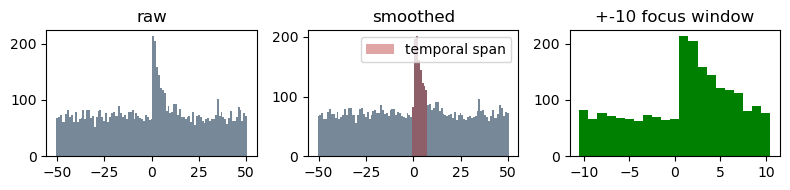

{'peak_height': np.float32(213.0), 'peak_lag': np.int64(1), 'peak_halfMax_width': np.int64(8), 'peak_to_noise': np.float32(15.861784), 'temporal_span': np.int64(8), 'entropy': np.float32(6.6087346), 'norm_entropy': np.float64(0.9925690442270523), 'norm_entropy_window': np.float64(0.9713841011534405), 'kl_divergence_window': np.float64(0.12568982275609014)}
---------------------------------------
dip occurs at bin 53 = 45.0 with lag = 3
dip drops to half in 7 bins
Tails: mean = 89.37999725341797, std = 8.298999786376953, dip_to_noise = 5.3480000495910645
Temporal span above threshold (72.78) = 11 bins around center
Entropy = 6.645999908447266
Normalized entropy = 0.998
Normalized entropy (±10 ms) = 0.993
KL divergence (±10 ms) = 0.032


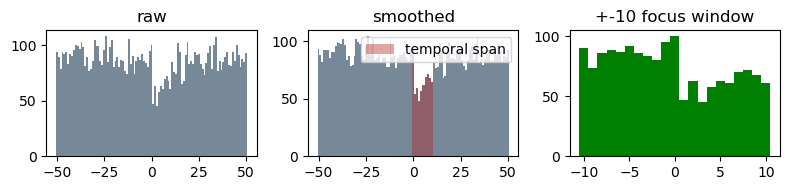

{'dip_depth': np.float32(45.0), 'dip_lag': np.int64(3), 'dip_halfMax_width': np.int64(7), 'dip_to_noise': np.float32(5.3475466), 'temporal_span': np.int64(11), 'entropy': np.float32(6.645773), 'norm_entropy': np.float64(0.998131848346353), 'norm_entropy_window': np.float64(0.9928222013441669), 'kl_divergence_window': np.float64(0.031527091008699035)}
---------------------------------------


In [8]:
_ = ccg_indicators(bs_ccg[0], connection_type='exc', smoothSigma=0.5, bin_size=1, peak_window_ms=10, ifVerbose=True, ifPlot=True, timebins=timebins, ifSave=False)
print(_); print('---------------------------------------')


_ = ccg_indicators(bs_ccg[20], connection_type='inh', smoothSigma=0.5, bin_size=1, peak_window_ms=10, ifVerbose=True, ifPlot=True, timebins=timebins, ifSave=False)
print(_); print('---------------------------------------')

### Digest - exc

In [9]:
i=0
fileTest = file_test_list[i]
featureDic = file_featureDics[i]
bs_ccg, ws, ls, ss = read_ccg(data_path, fileTest+'_CCG.csv') 
print('looking at', fileTest, ccg.shape)
ws[20]

looking at baseline (400, 101)


np.float64(-0.7)

peak happens at bin 51 = 213.0 with time lag = 1


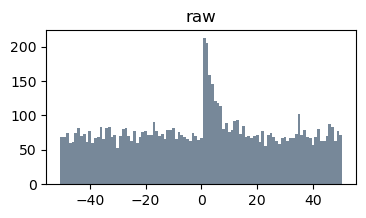

In [27]:
bin_size = 1
peak_window_ms = 10
center = len(ccg) // 2
baseline = np.mean(np.concatenate([ccg[:10], ccg[-10:]]))


ccg = bs_ccg[0] #327

# peak 
search_bins = int(peak_window_ms / bin_size)
search_region = ccg[center-search_bins : center+search_bins+1]

peak_idx_rel = np.argmax(search_region)
peak_idx = center - search_bins + peak_idx_rel
peak_val = ccg[peak_idx]
half_val = peak_val / 2
peak_lag = (peak_idx - center) * bin_size

print('peak happens at bin', peak_idx, '=', peak_val, 'with time lag =', peak_lag )

plt.figure(figsize=(4,2))
plt.bar(timebins, ccg, color=ccgColor, width=1); plt.title('raw'); plt.show()

In [28]:
# peak width (full width at half max)
half_val = peak_height / 2
left, right = peak_idx, peak_idx
while left > 0 and ccg[left] > half_val:
    left -= 1
while right < len(ccg) - 1 and ccg[right] > half_val:
    right += 1
peak_width = (right - left) * bin_size

print('peak drop to half in', peak_width, 'bins')
print(ccg[peak_idx:peak_idx+peak_width])

peak drop to half in 8 bins
[213. 205. 158. 145. 121. 118. 113.  81.]


In [64]:
# noise estimation from tails ----------------------------------
tail_bins = np.r_[np.arange(25), np.arange(len(ccg) - 25, len(ccg))]
noise_floor = np.mean(ccg[tail_bins])
noise_std = np.std(ccg[tail_bins])
peak_to_noise = ((peak_val - noise_floor) / (noise_std + 1e-10))

print('peak_to_noise =', peak_to_noise)

peak_to_noise = 15.861784875006274


entropy = 6.608734725342392 norm entropy = 0.9925690618963405


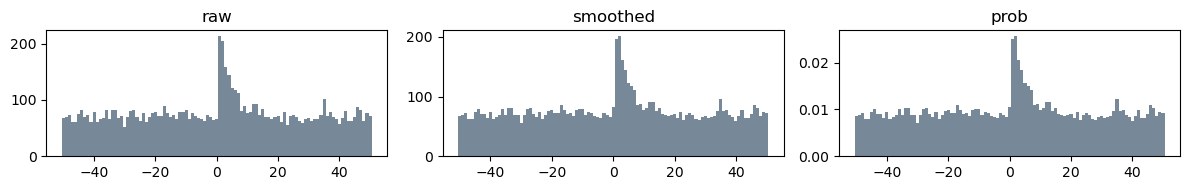

In [40]:
# entropy
ccg_smooth = gaussian_filter1d(ccg, sigma=0.5)
ccg_prob = ccg_smooth / (np.sum(ccg_smooth) + 1e-10)
ccg_entropy = entropy(ccg_prob, base=2)
ccg_entropy_norm = ccg_entropy / np.log2(len(ccg))
print('entropy =', ccg_entropy, 'norm entropy =', ccg_entropy_norm)

fig, ax = plt.subplots(1, 3, figsize=(12, 2))
ax[0].bar(timebins, ccg, color=ccgColor, width=1); ax[0].set_title('raw')
ax[1].bar(timebins, ccg_smooth, color=ccgColor, width=1); ax[1].set_title('smoothed')
ax[2].bar(timebins, ccg_prob, color=ccgColor, width=1); ax[2].set_title('prob')
plt.tight_layout(); plt.show()

kl_div = 0.08712157158879423


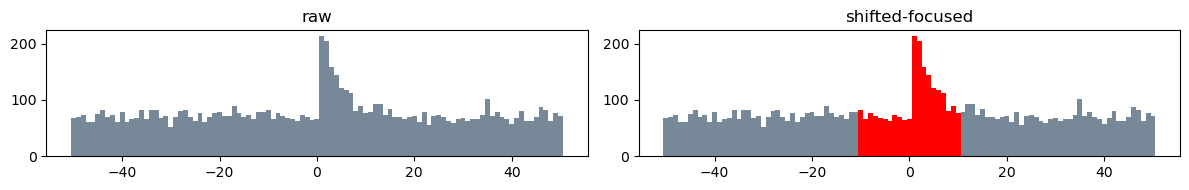

In [52]:
# KL divergence only within ±10 bins of the center
peak_window_ms = 10

window_bins = int(peak_window_ms / bin_size)
kl_window = ccg[center - window_bins:center + window_bins + 1]

P = kl_window / (np.sum(kl_window) + 1e-10)
U = np.ones_like(P) / len(P)
kl_div = np.sum(rel_entr(P, U)) / np.log(2) # in bits
print('kl_div =', kl_div)


fig, ax = plt.subplots(1, 2, figsize=(12, 2))
ax[0].bar(timebins, ccg, color=ccgColor, width=1); ax[0].set_title('raw')
ax[1].bar(timebins, ccg, color=ccgColor, width=1); 
ax[1].bar(timebins[center - window_bins:center + window_bins + 1], kl_window, color='r', width=1);ax[1].set_title('shifted-focused')
plt.tight_layout(); plt.show()

In [62]:
# entropy only within ±10 bins of the center

ccg_entropy_focus = entropy(P, base=2)
ccg_entropy_focus_norm = ccg_entropy_focus / np.log2(len(kl_window))
print('ccg_entropy_focus =', ccg_entropy_focus, 'ccg_entropy_focus_norm =', ccg_entropy_focus_norm)


ccg_entropy_focus = 4.2666275634930795 ccg_entropy_focus_norm = 0.971384158477744


from 50 to 58 bins, we have ccg above 0.25*peak/dip


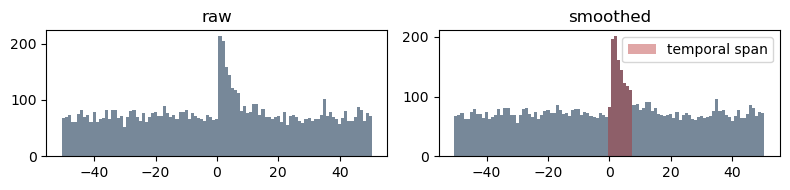

In [65]:
# Temporal span above noise threshold
thresh = noise_floor + 2 * noise_std
left_span, right_span = peak_idx, peak_idx
while left_span > 0 and ccg_smooth[left_span] > thresh:
    left_span -= 1
while right_span < len(ccg_smooth) - 1 and ccg_smooth[right_span] > thresh:
    right_span += 1
temporal_span = (right_span - left_span) * bin_size

print('from', left_span, 'to', right_span, 'bins, we have ccg above 0.25*peak/dip')

fig, ax = plt.subplots(1, 2, figsize=(8, 2))
ax[0].bar(timebins, ccg, color=ccgColor, width=1); ax[0].set_title('raw')
ax[1].bar(timebins, ccg_smooth, color=ccgColor, width=1); ax[1].set_title('smoothed')
ax[1].bar(timebins[left_span:right_span], ccg_smooth[left_span:right_span], 
          color=mC, width=1, alpha=0.4, label='temporal span'); ax[1].legend(loc=1)
plt.tight_layout(); plt.show()

### Digest - inh

dip peak happens at bin 53 = 45.0 with time lag = 3


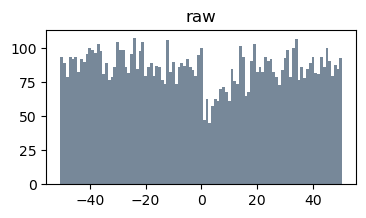

In [17]:
bin_size = 1
ccg = bs_ccg[20]


peak_window_ms = 10
search_bins = int(peak_window_ms / bin_size)
search_region = ccg[center-search_bins : center+search_bins+1]
baseline = np.mean(np.concatenate([ccg[:10], ccg[-10:]]))


# peak 
# center = len(ccg) // 2
# peak_height = np.min(ccg)
# peak_idx = np.argmin(ccg)
# peak_lag = (peak_idx - center) * bin_size

peak_idx_rel = np.argmin(search_region)
peak_idx = center - search_bins + peak_idx_rel
peak_val = ccg[peak_idx]
peak_lag = (peak_idx - center) * bin_size

print('dip peak happens at bin', peak_idx, '=', peak_val, 'with time lag =', peak_lag )

plt.figure(figsize=(4,2))
plt.bar(timebins, ccg, color=ccgColor, width=1); plt.title('raw'); plt.show()

In [20]:
# peak width (full width at half max)
# half_val = peak_height / 2
# left, right = peak_idx, peak_idx
# while left > 0 and ccg[left] < half_val:
#     left -= 1
# while right < len(ccg) - 1 and ccg[right] < half_val:
#     right += 1
# peak_width = (right - left) * bin_size

half_val = (peak_val + baseline) / 2
left, right = peak_idx, peak_idx
while left > 0 and (ccg[left] < half_val):
    left -= 1
while right < len(ccg) - 1 and  (ccg[right] < half_val):
    right += 1
peak_width = (right - left) * bin_size
print('peak drop to half in', peak_width, 'bins')
print(ccg[peak_idx:peak_idx+peak_width])

peak drop to half in 7 bins
[45. 58. 63. 61. 70. 72. 68.]


In [ ]:
# noise estimation from tails ----------------------------------
tail_bins = np.r_[np.arange(25), np.arange(len(ccg) - 25, len(ccg))]
noise_floor = np.mean(ccg[tail_bins])
noise_std = np.std(ccg[tail_bins])
peak_to_noise = ((peak_val - noise_floor) / (noise_std + 1e-10)) if connection_type == 'exc' else ((noise_floor - peak_val) / (noise_std + 1e-10))


entropy = 6.581543
normed entropy = 0.9884851188340283


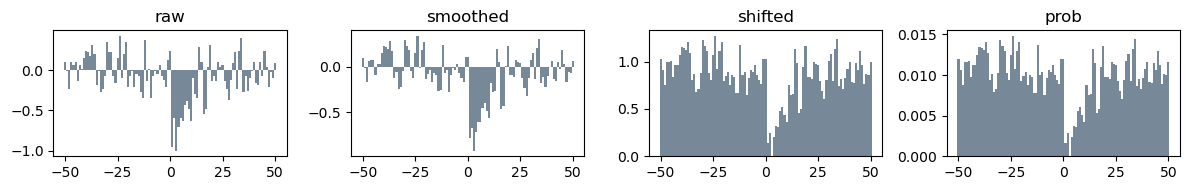

In [169]:
# entropy
ccg_smooth = gaussian_filter1d(ccg, sigma=0.5)
ccg_shifted = ccg_smooth - np.min(ccg_smooth) # shift to make in nonnegative
ccg_prob = ccg_shifted / (np.sum(ccg_shifted) + 1e-10)
ccg_entropy = entropy(ccg_prob, base=2)
ccg_entropy_norm =ccg_entropy / np.log2(len(ccg_smooth))
print('entropy =', ccg_entropy)
print('normed entropy =', ccg_entropy_norm)


fig, ax = plt.subplots(1, 4, figsize=(12, 2))
ax[0].bar(timebins, ccg, color=ccgColor, width=1); ax[0].set_title('raw')
ax[1].bar(timebins, ccg_smooth, color=ccgColor, width=1); ax[1].set_title('smoothed')
ax[2].bar(timebins, ccg_shifted, color=ccgColor, width=1); ax[2].set_title('shifted')
ax[3].bar(timebins, ccg_prob, color=ccgColor, width=1); ax[3].set_title('prob')
plt.tight_layout(); plt.show()

kl_div = 0.20893615


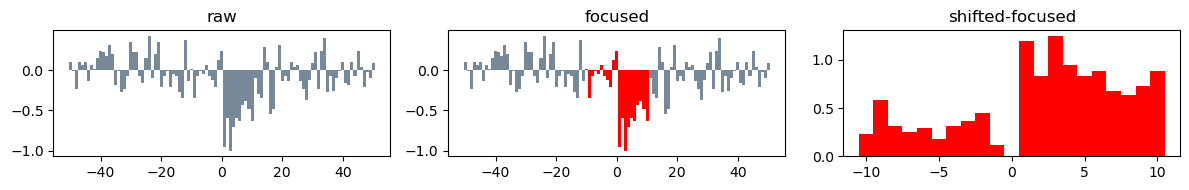

In [171]:
peak_window_ms = 10

window_bins = int(peak_window_ms / bin_size)
kl_window = ccg[center - window_bins:center + window_bins + 1]

# inh
kl_window =np.max(kl_window) - kl_window


P = kl_window / (np.sum(kl_window) + 1e-10)
U = np.ones_like(P) / len(P)
kl_div = np.sum(rel_entr(P, U))  # in bits
print('kl_div =', kl_div)


fig, ax = plt.subplots(1, 3, figsize=(12, 2))
ax[0].bar(timebins, ccg, color=ccgColor, width=1); ax[0].set_title('raw')
ax[1].bar(timebins, ccg, color=ccgColor, width=1); 
ax[1].bar(timebins[center - window_bins:center + window_bins + 1], ccg[center - window_bins:center + window_bins + 1], color='r', width=1);ax[1].set_title('focused')
ax[2].bar(timebins[center - window_bins:center + window_bins + 1], kl_window, color='r', width=1);ax[2].set_title('shifted-focused')

plt.tight_layout(); plt.show()

from 50 to 61 bins, we have ccg above 0.25*peak/dip


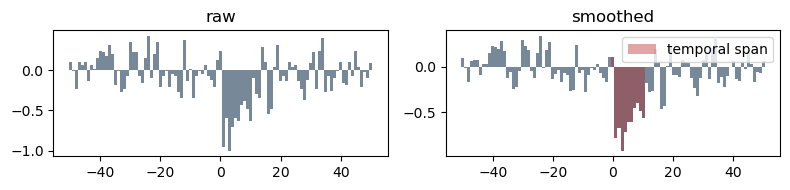

In [71]:
# Temporal span above noise threshold
thresh = 0.25 * peak_height
left_span, right_span = peak_idx, peak_idx
while left_span > 0 and ccg_smooth[left_span] < thresh:
    left_span -= 1
while right_span < len(ccg_smooth) - 1 and ccg_smooth[right_span] < thresh:
    right_span += 1
temporal_span = (right_span - left_span) * bin_size

print('from', left_span, 'to', right_span, 'bins, we have ccg above 0.25*peak/dip')

fig, ax = plt.subplots(1, 2, figsize=(8, 2))
ax[0].bar(timebins, ccg, color=ccgColor, width=1); ax[0].set_title('raw')
ax[1].bar(timebins, ccg_smooth, color=ccgColor, width=1); ax[1].set_title('smoothed')
ax[1].bar(timebins[left_span:right_span], ccg_smooth[left_span:right_span], 
          color=mC, width=1, alpha=0.4, label='temporal span'); ax[1].legend(loc=1)
plt.tight_layout(); plt.show()

### Function

In [70]:
def ccg_indicators(ccg, connection_type='exc', smoothSigma=0.5, bin_size=1, peak_window_ms=10, ifVerbose=False, ifPlot=False, timebins=None, figsize=(8,2), barColor='lightslategrey', spanColor='firebrick', ifSave=True, savePath=None, filename=None):
    '''
    Calculate signal indicators for CCGs.
    For excitatory connections (peaks) and inhibitory connections (dips), adjusts indicators accordingly.
    
    Returns: a dictionary with standardized keys:
        - peak_height or dip_depth
        - peak_to_noise or dip_to_noise
        - peak_halfMax_width or dip_halfMax_width
        - peak_lag or dip_lag
        - entropy
        - temporal_span
    '''
    
    
    ccg = np.array(ccg, dtype=np.float32)
    N = len(ccg); center = N // 2
    baseline = np.mean(np.concatenate([ccg[:10], ccg[-10:]]))


    # search for peak/dip -----------------------------------------
    # restrict to [-peak_window_ms,  peak_window_ms] range around the center, e.g., -10ms ~ 10ms
    search_bins = int(peak_window_ms / bin_size)
    search_region = ccg[center-search_bins : center+search_bins+1]
    if connection_type == 'exc':
        peak_idx_rel = np.argmax(search_region)
        peak_idx = center - search_bins + peak_idx_rel
        peak_val = ccg[peak_idx]
        direction = 'peak'
    elif connection_type == 'inh':
        peak_idx_rel = np.argmin(search_region)
        peak_idx = center - search_bins + peak_idx_rel
        peak_val = ccg[peak_idx]
        direction = 'dip'
    else:
        raise ValueError("connection_type must be 'exc' or 'inh'")
    
    peak_lag = (peak_idx - center) * bin_size


    # half-max width -----------------------------------------------
    half_val = peak_val / 2 if connection_type == 'exc' else (peak_val + baseline) / 2
    left, right = peak_idx, peak_idx
    while left > 0 and ((ccg[left] > half_val) if connection_type == 'exc' else (ccg[left] < half_val)):
        left -= 1
    while right < len(ccg) - 1 and ((ccg[right] > half_val) if connection_type == 'exc' else (ccg[right] < half_val)):
        right += 1
    peak_width = (right - left) * bin_size


    # noise estimation from tails ----------------------------------
    tail_bins = np.r_[np.arange(25), np.arange(len(ccg) - 25, len(ccg))]
    noise_floor = np.mean(ccg[tail_bins])
    noise_std = np.std(ccg[tail_bins])
    peak_to_noise = ((peak_val - noise_floor) / (noise_std + 1e-10)) if connection_type == 'exc' else ((noise_floor - peak_val) / (noise_std + 1e-10))


    # smooth for entropy and temporal span --------------------------
    ccg_smooth = gaussian_filter1d(ccg, sigma=smoothSigma)
    ccg_prob = ccg_smooth / (np.sum(ccg_smooth) + 1e-10)
    ccg_entropy = entropy(ccg_prob, base=2)
    ccg_entropy_norm = ccg_entropy / np.log2(N)

    # KL Divergence (+- 10ms window) ---------------------------------
    window_bins = int(peak_window_ms / bin_size)
    kl_window = ccg[center - window_bins:center + window_bins + 1]
    P = kl_window / (np.sum(kl_window) + 1e-10)
    U = np.ones_like(P) / len(P)
    kl_div = np.sum(rel_entr(P, U)) / np.log(2)  # in bits

    # entropy (+- 10ms window) -----------------------------------------
    window_entropy = entropy(P, base=2)
    window_entropy_norm = window_entropy / np.log2(len(P))


    # temporal span based on threshold
    thresh = noise_floor + 2 * noise_std if connection_type == 'exc' else noise_floor - 2 * noise_std
    left_span, right_span = peak_idx, peak_idx
    while left_span > 0 and ((ccg_smooth[left_span] > thresh) if connection_type == 'exc' else (ccg_smooth[left_span] < thresh)):
        left_span -= 1
    while right_span < len(ccg_smooth) - 1 and ((ccg_smooth[right_span] > thresh) if connection_type == 'exc' else (ccg_smooth[right_span] < thresh)):
        right_span += 1
    temporal_span = (right_span - left_span) * bin_size

    if ifVerbose:
        print(f"{direction} occurs at bin {peak_idx} = {peak_val} with lag = {peak_lag}")
        print(f"{direction} drops to half in {peak_width} bins")
        print(f"Tails: mean = {round(noise_floor, 3)}, std = {round(noise_std, 3)}, {direction}_to_noise = {round(peak_to_noise, 3)}")
        print(f"Temporal span above threshold ({thresh:.2f}) = {temporal_span} bins around center")
        print(f"Entropy = {round(ccg_entropy, 3)}")
        print(f"Normalized entropy = {ccg_entropy_norm:.3f}")
        print(f"Normalized entropy (±{peak_window_ms} ms) = {window_entropy_norm:.3f}")
        print(f"KL divergence (±{peak_window_ms} ms) = {kl_div:.3f}")
        

    if ifPlot:
        fig, ax = plt.subplots(1, 3, figsize=figsize)
        ax[0].bar(timebins, ccg, color=barColor, width=1); ax[0].set_title('raw')
        ax[1].bar(timebins, ccg_smooth, color=barColor, width=1); ax[1].set_title('smoothed')
        ax[1].bar(timebins[left_span:right_span], ccg_smooth[left_span:right_span], 
                  color=spanColor, width=1, alpha=0.4, label='temporal span'); ax[1].legend(loc=1)
        ax[2].bar(timebins[center-window_bins : center+window_bins+1], kl_window, color='g', width=1);ax[2].set_title('+-10 focus window')
        plt.tight_layout()
        if ifSave:
            if not os.path.exists(savePath):
                os.makedirs(savePath)
            plt.savefig(os.path.join(savePath, filename))
            plt.close()
        else:
            plt.show()

    # Return unified dictionary with consistent key naming
    result = {
        f"{direction}_height" if direction == 'peak' else "dip_depth": peak_val,
        f"{direction}_lag": peak_lag,
        f"{direction}_halfMax_width": peak_width,
        f"{direction}_to_noise": peak_to_noise,
        "temporal_span": temporal_span,
        "entropy": ccg_entropy,
        "norm_entropy": ccg_entropy_norm,
        'norm_entropy_window': window_entropy_norm, 
        "kl_divergence_window": kl_div 
    }

    return result



In [68]:
direction='dip'
f"{direction}_height" if direction == 'peak' else "dip_depth"

'dip_depth'